# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 2. Normalization and batch correction

This is the second part of the guide in which we normalise the gene counts, regress unwanted variation and batch correct the data. We also assign gene set scores for cell cycle and proliferation which will be used at a later stage to explore the data set. 

### Healthy dataset

This notebook shows the pipeline done on the "Healthy dataset" (see study for details regarding samples constituting the dataset). Here I am explaining the procedure step by step, so hopefully one can repeat it on their own data. In this repository there are also notebooks showing the same pipeline for other datasets from the study. I am not repeating the descriptions in those, so please always refer to the "Healthy dataset" notebooks while following the tutorial. 

Here I am working on 4 samples which I want to merge together into one condition - Healthy. You need to adjust the code accordingly to the number of samples/conditions you're working on. 

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv

#### 1. Load data

First lets load the file we have prepared in the previous part of the tutorial.

In [2]:
adata = sc.read('Healthy_qc.h5ad')

#### 2. Normalisation

In the previous step the samples have been joined into a single object `adata`. The samples, however, may have an intristic variation between each other, which either doesn't reflect the true biology (techincal variation) or represents the biological aspects we are not interested in (variation between test subjects within the same experimental condition). This type of variation is unwanted and could introduce biases in our analysis.  

This is why this part of the tutorial we adjust the count data so that the results are comparable between samples. First, we normalise and log transform the counts.

In bulk RNAseq it is common to normalise to counts per million (CPM normalisation). In scRNAseq that could mask the differnces between cells with different size transcriptoms. Therefore we choose to normalise per cell, that is "to the median of total counts for observations (cells) before normalization". Another important setting is the the `max_proportion_per_cell` parameter. This excludes genes counts that account for more than a specific proportion of cell size (5% in this case). This ensures that ubiquitously expressed genes (for examples housekeeping genes) do not influence the normalisation process. Also, note that we use the normalisation function from the `scVelo` package, as it also normalises the two RNA velocity layers (spliced and unspliced counts).  

In [3]:
scv.pp.normalize_per_cell(adata, max_proportion_per_cell=0.05)
scv.pp.log1p(adata)
adata.raw = adata

Normalized count data: X, spliced, unspliced.


It is critical that at this point we save the expression matrix to the `.raw` attribute of our object. It has to be done before the values are modified with any batch correction algorithms. We will use the "raw" values for Differential Expression (DE) analysis or when visualising gene marker expression.  

#### 3. Gene set scores

Before moving on with batch correction we first want to test which cells are cycling and proliferating. This is done through a sort of gene score calculation, by averaging expression of a supplied set of genes subtracted with the average expression of a reference set of genes. The reference set is randomly sampled from all the genes. The supplied set of genes depends on what are we testing for. Here, we look at proliferation and cell cycle. Those gene sets has been taken from the literature ([here](https://science.sciencemag.org/content/352/6282/189) and [here](https://www.sciencedirect.com/science/article/pii/S193459091100110X)) and can be found in the folder `Extra files` in this repository. 

The primary reason for looking into the two quantities is to be able to visualise them on a plot which will aid us in recognising cell types and differentiation patterns later on. Additionally, we will use the cell cycle information to subset the progenitors from the Healthy dataset, as well as regress the effect of cell cycle from the dataset (see step 5). 

In [4]:
# Load the list of genes associated with cell cycle.
cell_cycle_genes = [x.strip() for x in open('Extra files/cell_cycle_genes.txt')]
cell_cycle_genes = cell_cycle_genes[1:]
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

# Load the list of genes associated with proliferation.
proliferation_genes = [x.strip() for x in open('Extra files/proliferation_genes.txt')]

In [5]:
# Use a generic function for scoring gene set over expression.
sc.tl.score_genes(adata, proliferation_genes, score_name='Proliferation')

In [6]:
# Use function specifically for scoring cell cycle.
sc.tl.score_genes_cell_cycle(adata, s_genes=s_genes, g2m_genes=g2m_genes)

Note that the `sc.tl.score_genes_cell_cycle` function creates also `phase` field in the `adata` object which you can use to show all three cell cycle stages on one plot (instead of only plotting score for one of them). 

#### 4. Batch correction

In this step we perform batch correction on the data by using the `mnn_correct` function - scanpy's implementation of the mutual nearest neighbors (MNNs) algorithm. I will now explain it briefly using as a reference the figure below. When supplied with cells divided into different batches (fig. a), MNNs looks for cells with mutually similar expression (fig. b). Mutual means that both cells must be close in expression to each other (fig. b gray box). After detecing the pairs, the algorithm calculates correction vectors between the paired cells (fig. c). With the first batch regarded as a reference, the second batch is now integrated by substraction of the correction vectors (fig.d). This method can be applied iteratively over multiple batches (fig. e)

<div>
<img src="../Extra files/mnn.png" width="350"/>
</div>
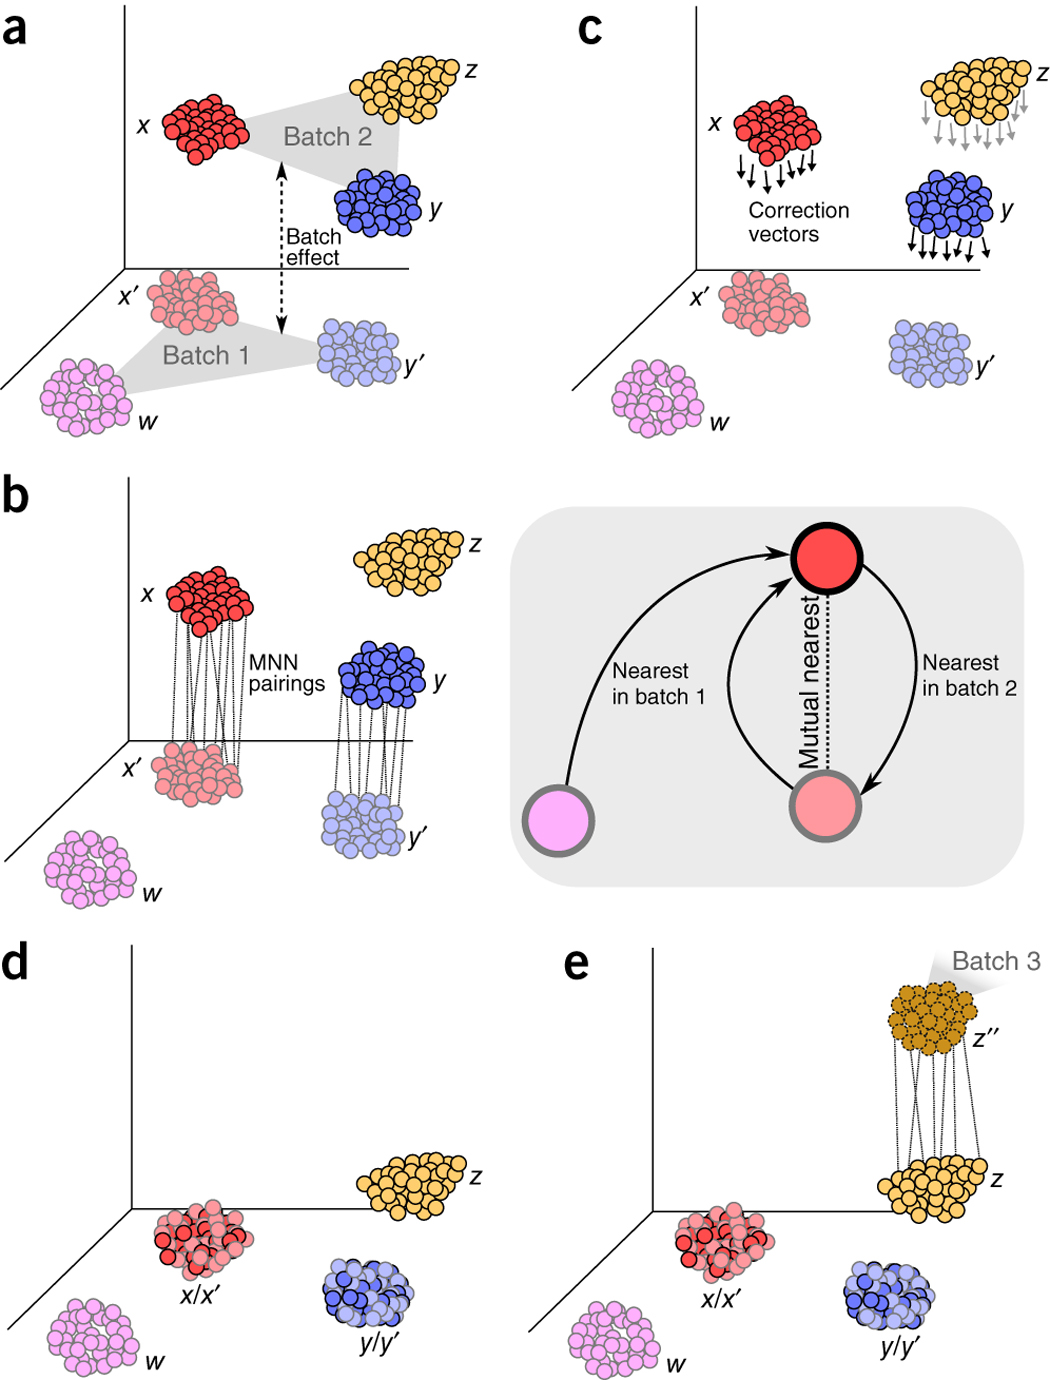

*Source: Haghverdi et al. (2018)*

Performing the batch correction on the whole set of genes would take far too long. Realistically, only the genes with variable expression across the dataset (across cell populations or samples) will significantly contribute to the batch effect. Therefore, we run the algorithm only on a subset of most highly variable genes. We keep the rest of the genes in the object (`subset=False`), since they may be intersting to look at later. 2000 genes is an arbitrary number, but seems to work fine on most datasets. You may want to adjust it accordingly depending on your data. 

In [7]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

The `mnn_correct` function does not return only the `adata` object, therefore it is better to save it to a temporary variable and extract `adata` from there. You may also find it useful when experimenting with the linear regression to reload the results of `mnn_correct` without having to recalculate it. 

**NB!** This step may take a VERY long time (>15 min).

In [8]:
corrected = sc.external.pp.mnn_correct(adata[adata.obs['Sample']=='healthy1'], adata[adata.obs['Sample']=='healthy2'], 
                                  adata[adata.obs['Sample']=='healthy3'], adata[adata.obs['Sample']=='healthy4'],
                                  var_subset=list(adata.var_names[adata.var['highly_variable']]), k=15, var_adj=True, 
                                  save_raw=True, n_jobs=12)

Performing cosine normalization...
Starting MNN correct iteration. Reference batch: 0
Step 1 of 3: processing batch 1
  Looking for MNNs...
  Computing correction vectors...
  Adjusting variance...
  Applying correction...
Step 2 of 3: processing batch 2
  Looking for MNNs...
  Computing correction vectors...
  Adjusting variance...
  Applying correction...
Step 3 of 3: processing batch 3
  Looking for MNNs...
  Computing correction vectors...
  Adjusting variance...
  Applying correction...
MNN correction complete. Gathering output...
Packing AnnData object...
Done.


In [9]:
adata = corrected[0].copy()

When it comes to the parameters of the function:

- first we give the objects divided by samples,
- `var_subset` specifies the subset of genes used when perfroming MNN correction,
- `k` is the number of mutual nearest neighbours. 15 was found to work well on this dataset. Default is 20. Increasing this number makes the correction more robust at the expense of removing more of the biological variation,
- `var_adj` indicates whether to adjust variance of the correction vectors. Can be disabled to save on computing time,
- `save_raw` saves the original expression in the `raw` attribute,
- `n_jobs` should be adjust to the number of cores in your processor. 

#### 4,5. (optional) Subset based on cell cycle

At this step (before regression) we may also want subset our adata object to include only progenitor cells. We define those as cells being in cell cycle, so having **positive S and/or G2M scores**. We will use the progenitor dataset at a separate part of this tutorial (look for `Healthy_Progen` notebooks). This is not a mandatory step and can be skipped if you are not interested in the progenitor population on its own.

In [10]:
G2M_cells = [name for name in adata.obs_names if adata.obs['G2M_score'][name] > 0]
S_cells = [name for name in adata.obs_names if adata.obs['S_score'][name] > 0]
CC_cells = set(G2M_cells + S_cells)
adata_progen = adata[list(CC_cells),:].copy()

#### 5. Linear regression

The final step in this part is to lineary regress (remove) the effect of cell cycle from the dataset. Specifically, we want to regress out the *S phase* and *G2M phase* in order to remove cycling patterns which negatively influence trajectory analysis and especially RNA velocity. 

In [11]:
sc.pp.regress_out(adata, ['S_score', 'G2M_score'])

... storing 'Sample' as categorical
... storing 'phase' as categorical


It is very important to note that there are other variables you may want to consider regressing in your dataset. Examples include: number of counts (count depth), percent of mitochondrial genes, percent of ribosomal genes. When correcting for multiple variables the regression should be performed over all of them in a single step to account for dependence between covariates.

#### 6. Save data for the next step 

In [12]:
adata.write("healthy_norm.h5ad")